# Week 5: Web Scraping and OCR
## IT 2012 - Unstructured Data

---
**Install requirements once:**
```
pip install requests beautifulsoup4 lxml pytesseract pillow pdf2image
```
Tesseract binary: https://github.com/UB-Mannheim/tesseract/wiki (Windows) | `brew install tesseract` (macOS) | `sudo apt install tesseract-ocr` (Linux)

In [1]:
import sys
!{sys.executable} -m pip install requests beautifulsoup4 lxml pytesseract pillow pandas

  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached pytesseract-0.3.13-py3-none-any.whl.metadata (11 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
Using cached requests-2.33.1-py3-none-any.whl (64 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 4.9 MB/s  0:00:01 eta 0:00:01
Using cached pytesseract-0.3.13-py3-none-any.whl (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 4.7 MB/s  0:00:02 eta 0:00:01
Using ca

In [2]:
# ── Imports for the whole notebook ────────────────────────────────────
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import time
import json
from PIL import Image, ImageFilter, ImageDraw, ImageFont
import pytesseract
import io
import textwrap

print('✅  All imports successful')

✅  All imports successful


---
## Part 1 — HTML, the DOM, and BeautifulSoup
### 1.1  What HTML looks like as a Python string

In [4]:
# Minimal HTML document — exactly what the browser receives
html_doc = """
<html>
  <head><title>IBU Demo Page</title></head>
  <body>
    <h1 id="main-title">Web Scraping Workshop</h1>
    <p class="intro">Learn to extract data from any website.</p>
    <ul id="topics">
      <li class="topic">BeautifulSoup</li>
      <li class="topic">Requests</li>
      <li class="topic">pytesseract</li>
    </ul>
    <a href="https://ibu.edu.ba" class="link">Visit IBU</a>
    <a href="/courses/it2012"    class="link">Course page</a>
    <p class="note">Price: <span class="price">49.99</span> KM</p>
  </body>
</html>
"""

print(html_doc)


<html>
  <head><title>IBU Demo Page</title></head>
  <body>
    <h1 id="main-title">Web Scraping Workshop</h1>
    <p class="intro">Learn to extract data from any website.</p>
    <ul id="topics">
      <li class="topic">BeautifulSoup</li>
      <li class="topic">Requests</li>
      <li class="topic">pytesseract</li>
    </ul>
    <a href="https://ibu.edu.ba" class="link">Visit IBU</a>
    <a href="/courses/it2012"    class="link">Course page</a>
    <p class="note">Price: <span class="price">49.99</span> KM</p>
  </body>
</html>



### 1.2  Parsing with BeautifulSoup

In [5]:
# Parse the HTML — this builds the DOM tree in Python
soup = BeautifulSoup(html_doc, 'html.parser')

# soup.prettify() shows the tree with indentation
print(soup.prettify())

<html>
 <head>
  <title>
   IBU Demo Page
  </title>
 </head>
 <body>
  <h1 id="main-title">
   Web Scraping Workshop
  </h1>
  <p class="intro">
   Learn to extract data from any website.
  </p>
  <ul id="topics">
   <li class="topic">
    BeautifulSoup
   </li>
   <li class="topic">
    Requests
   </li>
   <li class="topic">
    pytesseract
   </li>
  </ul>
  <a class="link" href="https://ibu.edu.ba">
   Visit IBU
  </a>
  <a class="link" href="/courses/it2012">
   Course page
  </a>
  <p class="note">
   Price:
   <span class="price">
    49.99
   </span>
   KM
  </p>
 </body>
</html>



### 1.3  Navigating the DOM tree — parent / child / sibling

In [6]:
# Get the <ul> element
ul = soup.find('ul', id='topics')
print('Element:', ul)
print()

# Children of <ul>
print('Direct children:')
for child in ul.children:
    if child.name:  # skip whitespace text nodes
        print(' ', child)

print()
# Parent of <ul>
print('Parent tag:', ul.parent.name)

# Siblings
first_li = ul.find('li')
print('First <li>:', first_li.get_text())
print('Next sibling:', first_li.find_next_sibling().get_text())

Element: <ul id="topics">
<li class="topic">BeautifulSoup</li>
<li class="topic">Requests</li>
<li class="topic">pytesseract</li>
</ul>

Direct children:
  <li class="topic">BeautifulSoup</li>
  <li class="topic">Requests</li>
  <li class="topic">pytesseract</li>

Parent tag: body
First <li>: BeautifulSoup
Next sibling: Requests


### 1.4  Finding elements — find() vs find_all() vs select()

In [7]:
# ── find() — first match only ─────────────────────────────────────────
h1 = soup.find('h1')
print('find(h1)        :', h1)

intro = soup.find('p', class_='intro')
print('find(p.intro)   :', intro)

title_el = soup.find(id='main-title')
print('find(id=main)   :', title_el)

print()

# ── find_all() — all matches ──────────────────────────────────────────
topics = soup.find_all('li', class_='topic')
print('find_all(li.topic):')
for t in topics:
    print(' ', t.get_text())

print()

# ── select() — CSS selector syntax ───────────────────────────────────
links = soup.select('a.link')         # all <a class="link">
price = soup.select_one('span.price') # first matching element
print('select(a.link)  :', [a.get_text() for a in links])
print('select_one(.price):', price.get_text())

find(h1)        : <h1 id="main-title">Web Scraping Workshop</h1>
find(p.intro)   : <p class="intro">Learn to extract data from any website.</p>
find(id=main)   : <h1 id="main-title">Web Scraping Workshop</h1>

find_all(li.topic):
  BeautifulSoup
  Requests
  pytesseract

select(a.link)  : ['Visit IBU', 'Course page']
select_one(.price): 49.99


### 1.5  Extracting data — text and attributes

In [8]:
# ── Text extraction ───────────────────────────────────────────────────
p_tag = soup.find('p', class_='note')

print('--- Text extraction ---')
print('.get_text()            :', repr(p_tag.get_text()))
print('.get_text(strip=True)  :', repr(p_tag.get_text(strip=True)))

print()

# ── Attribute extraction ──────────────────────────────────────────────
print('--- Attribute extraction ---')
link = soup.find('a', class_='link')

# Method 1: dict-style — raises KeyError if absent
print("link['href']          :", link['href'])

# Method 2: .get() — safe, returns None or default
print("link.get('href')      :", link.get('href'))
print("link.get('missing',''):", link.get('missing', 'NOT FOUND'))

print()

# ── All links and images on a page ───────────────────────────────────
print('--- All hrefs on the page ---')
for a in soup.find_all('a'):
    print(f'  text={a.get_text():20}  href={a.get("href")}')

--- Text extraction ---
.get_text()            : 'Price: 49.99 KM'
.get_text(strip=True)  : 'Price:49.99KM'

--- Attribute extraction ---
link['href']          : https://ibu.edu.ba
link.get('href')      : https://ibu.edu.ba
link.get('missing',''): NOT FOUND

--- All hrefs on the page ---
  text=Visit IBU             href=https://ibu.edu.ba
  text=Course page           href=/courses/it2012


---
## Part 2 — Scraping a Real Page
### 2.1  Downloading HTML with requests

In [9]:
# We use "books.toscrape.com" — a sandbox site made for scraping practice
BASE_URL = 'https://books.toscrape.com'

HEADERS = {
    'User-Agent': 'IT2012-Demo/1.0 (educational project; contact@ibu.edu.ba)'
}

response = requests.get(BASE_URL, headers=HEADERS)
response.raise_for_status()   # stops here if download failed

print('Status code    :', response.status_code)
print('Content-Type   :', response.headers.get('Content-Type'))
print('Response length:', len(response.text), 'characters')
print('First 300 chars:')
print(response.text[:300])

Status code    : 200
Content-Type   : text/html
Response length: 51294 characters
First 300 chars:
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lan


### 2.2  Single page extraction — book titles and prices

In [10]:
soup = BeautifulSoup(response.text, 'html.parser')

# Each book is in an <article class="product_pod">
books = soup.find_all('article', class_='product_pod')
print(f'Found {len(books)} books on this page\n')

results = []
for book in books[:5]:  # show first 5
    title  = book.find('h3').find('a')['title']     # full title in attribute
    price  = book.find('p', class_='price_color').get_text(strip=True)
    rating = book.find('p', class_='star-rating')['class'][1]  # e.g. 'Three'
    link   = urljoin(BASE_URL, book.find('h3').find('a')['href'])
    results.append({'title': title, 'price': price, 'rating': rating, 'url': link})

for r in results:
    print(f"📚 {r['title'][:45]:45}  {r['price']:8}  ⭐ {r['rating']}")

print(f'\n... and {len(books)-5} more books on this page')

Found 20 books on this page

📚 A Light in the Attic                           Â£51.77   ⭐ Three
📚 Tipping the Velvet                             Â£53.74   ⭐ One
📚 Soumission                                     Â£50.10   ⭐ One
📚 Sharp Objects                                  Â£47.82   ⭐ Four
📚 Sapiens: A Brief History of Humankind          Â£54.23   ⭐ Five

... and 15 more books on this page


### 2.3  Following links — scraping a book detail page

In [11]:
# Visit the detail page of the first book
detail_url = results[0]['url']
print('Visiting:', detail_url)

time.sleep(1)   # ← always be polite
detail_resp = requests.get(detail_url, headers=HEADERS)
detail_resp.raise_for_status()

dsoup = BeautifulSoup(detail_resp.text, 'html.parser')

# Extract structured data from the product page
title       = dsoup.find('h1').get_text()
price       = dsoup.find('p', class_='price_color').get_text(strip=True)
availability= dsoup.find('p', class_='availability').get_text(strip=True)
description = dsoup.find('div', id='product_description')
desc_text   = description.find_next_sibling('p').get_text(strip=True) if description else 'N/A'

# Product table (UPC, Type, Price, Availability, Reviews)
table = {}
for row in dsoup.select('table.table tr'):
    key = row.find('th').get_text(strip=True)
    val = row.find('td').get_text(strip=True)
    table[key] = val

print(f'\nTitle       : {title}')
print(f'Price       : {price}')
print(f'Availability: {availability}')
print(f'UPC         : {table.get("UPC", "N/A")}')
print(f'Description : {desc_text[:120]}...')

Visiting: https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html

Title       : A Light in the Attic
Price       : Â£51.77
Availability: In stock (22 available)
UPC         : a897fe39b1053632
Description : It's hard to imagine a world without A Light in the Attic. This now-classic collection of poetry and drawings from Shel ...


### 2.4  Handling pagination — scraping multiple pages

In [12]:
# Scrape the first 3 pages (20 books each = 60 books)
# NOTE: books.toscrape.com has 50 pages total — we stop at 3 to be polite

all_books = []
page = 1
max_pages = 3

while page <= max_pages:
    url = BASE_URL if page == 1 else f'{BASE_URL}/catalogue/page-{page}.html'
    print(f'  Scraping page {page}: {url}')

    resp = requests.get(url, headers=HEADERS)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, 'html.parser')

    for book in soup.find_all('article', class_='product_pod'):
        all_books.append({
            'title' : book.find('h3').find('a')['title'],
            'price' : book.find('p', class_='price_color').get_text(strip=True),
            'rating': book.find('p', class_='star-rating')['class'][1],
        })

    # Check for Next button — stop if not found
    next_btn = soup.find('li', class_='next')
    if not next_btn:
        print('  No more pages.')
        break

    page += 1
    time.sleep(1)  # ← be polite between requests

print(f'\nTotal books collected: {len(all_books)}')
print(f'Price range: {min(b["price"] for b in all_books)} – {max(b["price"] for b in all_books)}')

# Rating distribution
from collections import Counter
ratings = Counter(b['rating'] for b in all_books)
print('\nRating distribution:')
for star, count in sorted(ratings.items()):
    bar = '█' * count
    print(f'  {star:10}: {bar} ({count})')

  Scraping page 1: https://books.toscrape.com
  Scraping page 2: https://books.toscrape.com/catalogue/page-2.html
  Scraping page 3: https://books.toscrape.com/catalogue/page-3.html

Total books collected: 60
Price range: Â£12.84 – Â£57.31

Rating distribution:
  Five      : ██████████████ (14)
  Four      : ██████████ (10)
  One       : ███████████████ (15)
  Three     : █████████████ (13)
  Two       : ████████ (8)


### 2.5  ⚠️  Data validation — the silent failure demo

In [14]:
# Simulate what happens when a site switches to JavaScript rendering.
# The scraper gets a response with no real data — but it never crashes.

js_rendered_page = """
<html><body>
  <div class="product">
    <span class="price"></span>  <!-- price injected by JS — empty in initial HTML -->
    <span class="name">Laptop Pro X</span>
  </div>
</body></html>
"""

def scrape_price(html):
    s = BeautifulSoup(html, 'html.parser')
    el = s.find('span', class_='price')
    return el.get_text(strip=True) if el else None

price = scrape_price(js_rendered_page)
print(f'Scraped price: {repr(price)}')
print(f'Type: {type(price)}')
print(f'Truthy? {bool(price)}')
print()
print('The scraper returned NO error. It returned an empty string.')
print('If you stored this in a database for 6 weeks, you have 6 weeks of blank prices.')
print()

# ── The fix: always validate what you extract ──────────────────────────
import re

def scrape_price_safe(html, source_url='unknown'):
    s = BeautifulSoup(html, 'html.parser')
    el = s.find('span', class_='price')
    raw = el.get_text(strip=True) if el else ''

    # Validate: must look like a real price
    if not raw:
        raise ValueError(f'Empty price at {source_url} — page may be JS-rendered')
    if not re.match(r'^[\d,\.]+$', raw.replace('$','').replace('€','').replace('KM','').strip()):
        raise ValueError(f'Suspicious price {repr(raw)} at {source_url}')

    return raw

try:
    scrape_price_safe(js_rendered_page, 'https://example.com/product/1')
except ValueError as e:
    print(f'✅  Caught the problem: {e}')

Scraped price: ''
Type: <class 'str'>
Truthy? False

The scraper returned NO error. It returned an empty string.
If you stored this in a database for 6 weeks, you have 6 weeks of blank prices.

✅  Caught the problem: Empty price at https://example.com/product/1 — page may be JS-rendered


### 2.6  Ethics — inspecting robots.txt

In [15]:
# Always check robots.txt before scraping a new site
robots = requests.get('https://books.toscrape.com/robots.txt')
print('robots.txt for books.toscrape.com:')
print(robots.text)
print()
print('Compare with a site that restricts scraping:')
robots2 = requests.get('https://www.amazon.com/robots.txt')
# Show just first 20 lines
lines = robots2.text.splitlines()
for line in lines[:20]:
    print(line)
print(f'... ({len(lines)} lines total)')

robots.txt for books.toscrape.com:
<html>
<head><title>404 Not Found</title></head>
<body>
<center><h1>404 Not Found</h1></center>
<hr><center>nginx/1.21.6</center>
</body>
</html>


Compare with a site that restricts scraping:
User-agent: *
Disallow: /exec/obidos/account-access-login
Disallow: /exec/obidos/change-style
Disallow: /exec/obidos/flex-sign-in
Disallow: /exec/obidos/handle-buy-box
Disallow: /exec/obidos/tg/cm/member/
Disallow: /gp/aw/help/id=sss
Disallow: /gp/cart
Disallow: /gp/flex
Disallow: /gp/product/e-mail-friend
Disallow: /gp/product/product-availability
Disallow: /gp/product/rate-this-item
Disallow: /gp/sign-in
Disallow: /gp/reader
Disallow: /gp/sitbv3/reader
Disallow: /gp/richpub/syltguides/create
Disallow: /gp/gfix
Disallow: /gp/associations/wizard.html
Disallow: /gp/dmusic/order
Disallow: /gp/legacy-handle-buy-box.html
... (281 lines total)


### 2.7  Dynamic content — finding the hidden JSON API

In [16]:
# Many sites that look dynamic actually call a JSON API under the hood.
# This is faster and more reliable than Selenium.
# Example: Open Library public API (no key needed)

print('Calling the Open Library search API directly (JSON endpoint)...')

api_url = 'https://openlibrary.org/search.json'
params = {'q': 'python programming', 'limit': 5, 'fields': 'title,author_name,first_publish_year'}

resp = requests.get(api_url, params=params, headers=HEADERS)
resp.raise_for_status()

data = resp.json()   # directly parse JSON — no BeautifulSoup needed
print(f'Total results: {data["numFound"]}\n')
print(f'{"Title":50} {"Author":25} {"Year"}')
print('-' * 85)
for book in data['docs']:
    title  = book.get('title', 'N/A')[:48]
    author = ', '.join(book.get('author_name', ['N/A']))[:23]
    year   = book.get('first_publish_year', '?')
    print(f'{title:50} {author:25} {year}')

print()
print('💡  This is much cleaner than scraping HTML rendered by JavaScript.')
print('    Always check the Network tab in DevTools first!')

Calling the Open Library search API directly (JSON endpoint)...
Total results: 2478

Title                                              Author                    Year
-------------------------------------------------------------------------------------
Core Python Programming                            R. Nageswara Rao          2016
Core Python programming                            Wesley Chun               2006
Black Hat Python                                   Justin Seitz, Tim Arnol   2014
Python Programming                                 Reema Thareja             2019
Python                                             Joshua Welsh              2017

💡  This is much cleaner than scraping HTML rendered by JavaScript.
    Always check the Network tab in DevTools first!


---
## Part 3 — OCR with pytesseract
### 3.1  Creating a test image with text

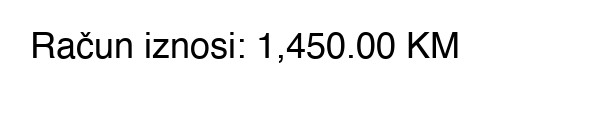

✅  Clean image created


In [10]:
from IPython.display import display

def make_text_image(text, font_size=36, noise=False, skew=False, low_res=False,
                    bg_color='white', text_color='black', size=(600, 120)):
    """Create a PIL image containing text — used for OCR demos."""
    img = Image.new('RGB', size, color=bg_color)
    draw = ImageDraw.Draw(img)

    # Use default PIL font (no external font file needed)
    try:
        from PIL import ImageFont
        font = ImageFont.truetype('/System/Library/Fonts/Helvetica.ttc', font_size)
    except Exception:
        font = ImageFont.load_default()

    draw.text((30, 30), text, fill=text_color, font=font)

    if noise:
        import random
        pixels = img.load()
        for _ in range(3000):
            x, y = random.randint(0, size[0]-1), random.randint(0, size[1]-1)
            pixels[x, y] = random.choice([(0,0,0), (200,200,200)])

    if skew:
        import math
        img = img.rotate(8, fillcolor='white', expand=False)

    if low_res:
        img = img.resize((size[0]//4, size[1]//4), Image.NEAREST)
        img = img.resize(size, Image.NEAREST)

    return img

# Show the clean base image
#img_clean = make_text_image('Invoice total: 1,450.00 KM')
img_clean = make_text_image('Račun iznosi: 1,450.00 KM')

display(img_clean)
print('✅  Clean image created')

### 3.2  Basic OCR — image_to_string()

In [11]:
# Basic OCR — just pass the image and get text back
text = pytesseract.image_to_string(img_clean, lang='bos')


print('OCR result (raw):')

print(repr(text))
print()

print('Stripped:', text.strip())

OCR result (raw):
'Račun iznosi: 1,450.00 KM\n'

Stripped: Račun iznosi: 1,450.00 KM


### 3.3  Output formats — data, boxes, OSD

In [19]:
import pandas as pd

# image_to_data — word-level bounding boxes + confidence scores
df = pytesseract.image_to_data(img_clean, output_type=pytesseract.Output.DATAFRAME)

# Show only rows with actual text (confidence > 0)
words = df[df.conf > 0][['word_num', 'text', 'conf', 'left', 'top', 'width', 'height']]
print('Word-level data:')
print(words.to_string(index=False))

print()
print(f'Average confidence: {words.conf.mean():.1f}%')
print(f'Lowest confidence word: "{words.loc[words.conf.idxmin(), "text"]}" ({words.conf.min():.0f}%)')

Word-level data:
 word_num     text      conf  left  top  width  height
        1  Invoice 78.179489    31   32     97       9
        2   total: 25.650158    66   22     22      28
        3 1,450.00 62.121391    89   32     39       9
        4       KM 46.972809   132   32     13       8

Average confidence: 53.2%
Lowest confidence word: "total:" (26%)


### 3.4  Before and after preprocessing — the impact on accuracy

In [21]:
def preprocess(img):
    """Apply the 5-step preprocessing pipeline from the slides."""
    # Step 1: Rescale to ≥ 300 DPI equivalent
    w, h = img.size
    img = img.resize((w * 2, h * 2), Image.LANCZOS)

    # Step 2: Greyscale
    img = img.convert('L')

    # Step 3: Noise removal (median filter)
    img = img.filter(ImageFilter.MedianFilter(size=3))

    # Step 4: Binarise (Otsu-style simple threshold)
    img = img.point(lambda x: 0 if x < 140 else 255, '1')
    img = img.convert('RGB')  # pytesseract needs RGB

    # Step 5: Deskew (use image_to_osd to detect angle)
    # (Deskew demo is in the next cell — requires detectably skewed image)
    return img

# ── Create degraded images for demo ───────────────────────────────────
test_text = 'Total: 2,890 KM — Due 2025-06-01'

scenarios = [
    ('Clean',           make_text_image(test_text)),
    ('Noisy',           make_text_image(test_text, noise=True)),
    ('Low resolution',  make_text_image(test_text, low_res=True)),
    ('Noisy + Low res', make_text_image(test_text, noise=True, low_res=True)),
]

print(f'{"Condition":20}  {"Raw OCR result":45}  {"After preprocessing"}')
print('-' * 100)

for name, img in scenarios:
    raw    = pytesseract.image_to_string(img).strip().replace('\n', ' ')
    fixed  = pytesseract.image_to_string(preprocess(img)).strip().replace('\n', ' ')
    ok_raw = '✅' if test_text[:6] in raw    else '❌'
    ok_fix = '✅' if test_text[:6] in fixed   else '❌'
    print(f'{name:20}  {ok_raw} {raw[:42]:43}  {ok_fix} {fixed[:40]}')

Condition             Raw OCR result                                 After preprocessing
----------------------------------------------------------------------------------------------------
Clean                 ❌ Total 2.890 KM Due 2025-08-01                ❌ Total 2.890 Ki Due 2025.06.01
Noisy                 ❌ “Feat niin asso                              ❌ . Tout 2.890 KMa Due 2025.05:01
Low resolution        ❌                                              ❌ 
Noisy + Low res       ❌ -                                            ❌ -


### 3.5  Deskewing — detecting and correcting page rotation

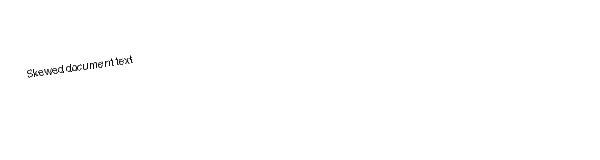

OSD note: (1, 'Estimating resolution as 112 Too few characters. Skipping this page Warning. Invalid resolution 0 dpi. Using 70 instead. Too few characters. Skipping this page Error during processing.')
(OSD works best on full pages with multiple lines of text)
Manually rotating as demonstration:


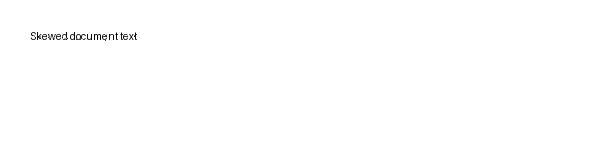

In [22]:
import re

# Create a skewed image
img_skewed = make_text_image('Skewed document text', skew=True, size=(600, 160))
display(img_skewed)

# Detect rotation angle
try:
    osd = pytesseract.image_to_osd(img_skewed)
    print('OSD output:')
    print(osd)

    match = re.search(r'Rotate: (\d+)', osd)
    if match:
        angle = int(match.group(1))
        print(f'Detected rotation: {angle}°')
        if angle != 0:
            img_corrected = img_skewed.rotate(-angle, fillcolor='white', expand=True)
            display(img_corrected)
            print('✅  Image deskewed')
except pytesseract.pytesseract.TesseractError as e:
    # OSD needs enough text to work — may fail on short strings
    print(f'OSD note: {e}')
    print('(OSD works best on full pages with multiple lines of text)')
    print('Manually rotating as demonstration:')
    img_corrected = img_skewed.rotate(-8, fillcolor='white', expand=False)
    display(img_corrected)

### 3.6  Language support and config flags

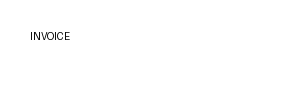

--- PSM mode comparison ---
  psm=3 (auto (default)): 'INVOICE'
  psm=7 (single line): 'INVOICE'
  psm=8 (single word): 'om'
  psm=6 (block of text): 'INVOICE'


In [27]:
# Show the effect of --psm (page segmentation mode)
single_word_img = make_text_image('INVOICE', font_size=60, size=(300, 100))
display(single_word_img)

print('--- PSM mode comparison ---')
for psm, desc in [(3, 'auto (default)'), (7, 'single line'), (8, 'single word'), (6, 'block of text')]:
    result = pytesseract.image_to_string(
        single_word_img,
        config=f'--oem 3 --psm {psm}'
    ).strip()
    print(f'  psm={psm} ({desc}): {repr(result)}')


### 3.7  Full pipeline — simulating a scanned PDF page

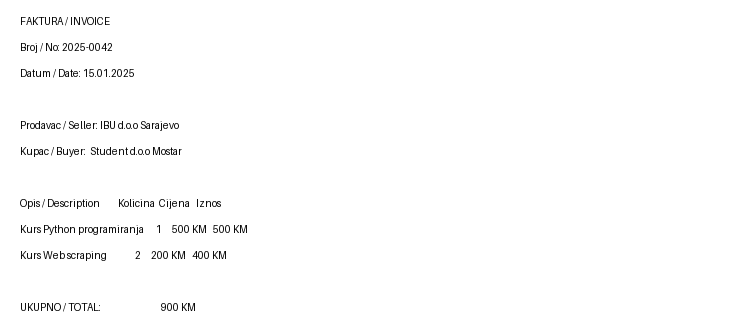


--- Raw OCR (no preprocessing) ---
FAKTURA/ INVOICE
Bro] Ne: 2025-0042

Datum / Date: 15.01.2025

Predavac/ Seller IBU dao Sarajevo

Kupac/ Buyer: Studentd.oo Mostar

Opis/ Description Kolicina Cijena Lznos

kKursPython programiranja 1 500 KM 500 KM

KursWebseraping 2200 KM_ 400 KM

UKUPNO/ TOTAL: 900 km

--- After preprocessing ---
FAKTURA: INVOICE
Groy * No 20250042

Datum Date 1501 2025

Prodavac ; Seller IBU dao Sarajevo

Kupac - Buyer Studentd oo Mostar

Opis / Description Kolicina Ciena Iznos

Kurs Python programiranja 1 500 KM 500 KM

Kurs Webscraping 2 200 KM 400 KM

UKUPNO: TOTAL 900 Ki


✅  Extracted total: 900


In [28]:
# Simulate a realistic scanned invoice page
invoice_text = (
    "FAKTURA / INVOICE\n"
    "Broj / No: 2025-0042\n"
    "Datum / Date: 15.01.2025\n"
    "\n"
    "Prodavac / Seller: IBU d.o.o Sarajevo\n"
    "Kupac / Buyer:  Student d.o.o Mostar\n"
    "\n"
    "Opis / Description         Kolicina  Cijena   Iznos\n"
    "Kurs Python programiranja      1     500 KM   500 KM\n"
    "Kurs Web scraping              2     200 KM   400 KM\n"
    "\n"
    "UKUPNO / TOTAL:                              900 KM"
)

# Create a clean version and a degraded 'scanned' version
img_invoice_clean = Image.new('RGB', (750, 320), 'white')
draw = ImageDraw.Draw(img_invoice_clean)
try:
    from PIL import ImageFont
    font_sm = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 18)
    font_bold = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 20)
except:
    font_sm = font_bold = ImageFont.load_default()

y = 15
for i, line in enumerate(invoice_text.split('\n')):
    f = font_bold if i == 0 else font_sm
    draw.text((20, y), line, fill='black', font=f)
    y += 26

# Add a light grey scan background to simulate a scanner
import random
pixels = img_invoice_clean.load()
for _ in range(2000):
    x = random.randint(0, 749)
    y_p = random.randint(0, 319)
    r, g, b = pixels[x, y_p]
    pixels[x, y_p] = (min(255, r+30), min(255, g+30), min(255, b+30))

display(img_invoice_clean)

# ── Now OCR it ─────────────────────────────────────────────────────────
print('\n--- Raw OCR (no preprocessing) ---')
raw = pytesseract.image_to_string(img_invoice_clean)
print(raw)

print('--- After preprocessing ---')
processed = preprocess(img_invoice_clean)
clean = pytesseract.image_to_string(processed)
print(clean)

# ── Extract total from OCR output ──────────────────────────────────────
#total_match = re.search(r'TOTAL[:\s]+([\d,\.]+\s*KM)', clean, re.IGNORECASE)
total_match = re.search(r'TOTAL[:\s]+([\d,\.]+)', clean, re.IGNORECASE)

if total_match:
    print(f'\n✅  Extracted total: {total_match.group(1)}')
else:
    print('\n❌  Total not found in OCR output — check preprocessing')

---
## Summary

| Topic | Key takeaway |
|---|---|
| BeautifulSoup | `find()` / `find_all()` / `select()` — always use `.get_text(strip=True)` and `.get('attr', '')` |
| requests | `raise_for_status()` every time, set a `User-Agent`, sleep between requests |
| Pagination | Loop while `next_btn` exists — stop gracefully |
| Data validation | A scraper that never crashes is NOT a scraper that works |
| Dynamic content | Check the Network tab first — JSON API beats Playwright every time |
| pytesseract | `image_to_string()` for text, `image_to_data()` for confidence scores |
| Preprocessing | Rescale → greyscale → binarise → denoise → deskew |

---
*IT 2012 – Unstructured Data · Week 5 · International Burch University*